# 🐶 Stanford Dogs Classifier - Inference Demo

<a href="https://colab.research.google.com/github/AgentBooster/portfolio-projects/blob/main/Machine_Learning_Deep_Learning/vision_image_classifier_cnn/notebooks/demo_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to the **Interactive Inference Demo** for the Stanford Dogs Classifier. This notebook demonstrates how to load our trained professional-grade model and use it to classify new images of dogs.

### ℹ️ Note on Google Colab
If you are running this in Google Colab, the code will clone the repository into the **temporary** cloud environment (`/content`). 
**It will NOT affect your local files or your GitHub portfolio.** The environment is ephemeral and disappears when you close the tab.

### 🎯 Objectives
1.  **Load the Model**: Import the trained `.keras` model from disk.
2.  **Load Labels**: Map the model's numeric output to human-readable dog breeds.
3.  **The Inference Pipeline**: Understand the exact preprocessing steps required (Resize -> Scale -> Expand Dims) to avoid _domain shift_.
4.  **Visualize Results**: Display the image alongside the model's top predictions.

---

## 1. Setup Environment (Colab & Local)
This cell ensures the notebook runs correctly whether on Google Colab or your local machine.

In [13]:
import os
import sys
from pathlib import Path

# --- COLAB SETUP ---
if 'google.colab' in sys.modules:
    print("☁️ Running in Google Colab...")
    
    # 1. Clone Repo
    if not os.path.exists('portfolio-projects'):
        print("📥 Cloning repository (Read-Only)...")
        # The !git clone command may fail if the repo is Private or not yet pushed to GitHub.
        # We use || true to prevent the cell from crashing on error, so we can print a helpful message.
        !git clone https://github.com/AgentBooster/portfolio-projects.git || echo "Clone failed"
    
    # 2. Check Directory Structure
    PROJECT_DIR = 'portfolio-projects/Machine_Learning_Deep_Learning/vision_image_classifier_cnn'
    if os.path.exists(PROJECT_DIR):
        os.chdir(PROJECT_DIR)
        print(f"✅ Directory changed to: {os.getcwd()}")
        
        # 3. Install dependencies
        print("📦 Installing dependencies...")
        !pip install -r requirements.txt
        print("✅ Environment ready!")
    else:
        print("\n❌ CRITICAL ERROR: Repo Cloning Failed or Directory Not Found.")
        print(f"Expected path: /content/{PROJECT_DIR}")
        print("\nPossible causes:")
        print("1. The repository 'AgentBooster/portfolio-projects' is Private (Make it Public!).")
        print("2. You haven't PUSHED the latest code to GitHub yet.")
        print("3. The directory structure on GitHub is different than expected.")
else:
    print("💻 Running locally...")

# --- COMMON SETUP ---
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('.').resolve()
sys.path.append(str(PROJECT_ROOT))

print(f"Project Root: {PROJECT_ROOT}")
print(f"TensorFlow Version: {tf.__version__}")

☁️ Running in Google Colab...
📥 Cloning repository (Read-Only)...
Cloning into 'portfolio-projects'...
remote: Enumerating objects: 598, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 598 (delta 0), reused 1 (delta 0), pack-reused 591 (from 1)
Receiving objects: 100% (598/598), 25.95 MiB | 35.62 MiB/s, done.
Resolving deltas: 100% (204/204), done.
✅ Directory changed to: /content/portfolio-projects/Machine_Learning_Deep_Learning/vision_image_classifier_cnn
📦 Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 792.0 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 55.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 116.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━

✅ Environment ready!
Project Root: /content/portfolio-projects/Machine_Learning_Deep_Learning/vision_image_classifier_cnn
TensorFlow Version: 2.19.0


## 2. Load Model and Labels

### ⚠️ Essential Step for Colab Users
Since the trained model file (`.keras`) is large, it is typically not stored in the Git repository. 
If you are running this in Colab, you need to either **Train the Model** (recommended, takes ~5-10 mins with GPU) or upload your own model file to the `models/` folder.

Run the cell below to check for the model and train if missing.

In [15]:
# Paths
MODEL_PATH = PROJECT_ROOT / 'models' / 'mobilenetv2_dogs.keras'
LABELS_PATH = PROJECT_ROOT / 'models' / 'labels.txt'

# Check if model exists
if not MODEL_PATH.exists():
    print(f"⚠️ Model not found at {MODEL_PATH}")
    
    if 'google.colab' in sys.modules:
        if os.path.exists('src/train.py'):
            print("\n🚀 Initiating Fast Training Pipeline (MobileNetV2)...")
            print("This will download the dataset and train for a few epochs to generate a model for demo purposes.")
            
            # Run the training script directly! 
            # We use !python to run it as a shell command in the environment
            !python src/train.py
            
            print("\n✅ Training complete! Model should now be available.")
        else:
            print("❌ Cannot train: 'src/train.py' not found (Repository clone failed).")
            print("Please fix the repository visibility (Public) and re-run Cell 1.")
    else:
        print("❌ Please run 'python src/train.py' in your terminal to train the model first.")
else:
    print(f"✅ Model found at {MODEL_PATH}")

# Load Model (Only if it exists now)
if MODEL_PATH.exists():
    print("Loading model... this may take a moment.")
    model = tf.keras.models.load_model(MODEL_PATH)
    print("✅ Model loaded successfully!")

# Load Labels
if LABELS_PATH.exists():
    with open(LABELS_PATH, 'r') as f:
        LABELS = [line.strip() for line in f.readlines()]
    print(f"✅ Loaded {len(LABELS)} class labels.")
else:
    print("⚠️ Warning: labels.txt not found. Using generic indices.")
    LABELS = [f"Class {i}" for i in range(120)]

✅ Model found at /content/portfolio-projects/Machine_Learning_Deep_Learning/vision_image_classifier_cnn/models/mobilenetv2_dogs.keras
Loading model... this may take a moment.
✅ Model loaded successfully!
✅ Loaded 120 class labels.


## 3. The Inference Pipeline

Professional inference is not just `model.predict(image)`. We must strictly replicate the preprocessing used during training:

1.  **Resize**: The model expects 224x224 pixels.
2.  **Cast**: Convert inputs to Float32.
3.  **Preprocess**: Apply `mobilenet_v2.preprocess_input` (scales pixel values between -1 and 1).
4.  **Batch Dimension**: The model expects a batch of images `(Batch, Height, Width, Channels)`, so we add a dimension to make it `(1, 224, 224, 3)`.

> **Crucial**: Failing to normalize correctly is the #1 reason for poor inference performance.

In [16]:
def preprocess_image(image_path):
    """
    Loads and preprocesses an image for MobileNetV2 inference.
    """
    # 1. Load image and resize to target size (224, 224)
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    
    # 2. Convert to array
    img_array = tf.keras.utils.img_to_array(img)
    
    # 3. Create batch axis (H, W, C) -> (1, H, W, C)
    img_batch = tf.expand_dims(img_array, 0)
    
    # 4. MobileNetV2 specific preprocessing (scaling to [-1, 1])
    img_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(img_batch)
    
    return img, img_preprocessed

## 4. Run Prediction

Let's create a function to predict and visualize the top 5 confidence scores.

In [17]:
def predict_and_visualize(image_path):
    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return

    # Preprocess
    original_img, processed_img = preprocess_image(image_path)

    # Inference
    predictions = model.predict(processed_img, verbose=0)
    probabilities = predictions[0]  # Get the first (and only) item in batch

    # Decoding Top 5
    top_indices = np.argsort(probabilities)[-5:][::-1]
    
    # Visualization
    plt.figure(figsize=(10, 4))
    
    # Subplot 1: Image
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.axis('off')
    plt.title("Input Image")

    # Subplot 2: Bar Chart
    plt.subplot(1, 2, 2)
    top_probs = probabilities[top_indices] * 100
    top_labels = [LABELS[i] for i in top_indices]
    
    colors = ['#3843d0' if i == 0 else '#b0b8ff' for i in range(len(top_probs))]
    bars = plt.barh(top_labels[::-1], top_probs[::-1], color=colors[::-1])
    plt.xlabel('Confidence (%)')
    plt.title(f"Top Prediction: {top_labels[0]} ({top_probs[0]:.2f}%)")
    plt.xlim(0, 110)
    
    # Add text labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                 va='center', fontweight='bold', color='#333')

    plt.tight_layout()
    plt.show()

## 5. Demo Time!
Change the `SAMPLE_IMAGE_PATH` below to point to any image in `ui/images/` or upload a new one to Colab.

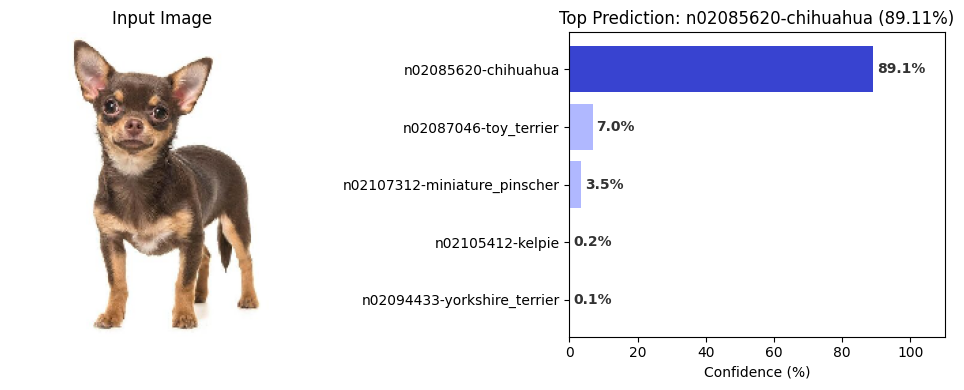

In [18]:
# Example image from our UI folder
# You can change this to any path, e.g., '../data/my_dog.jpg'
SAMPLE_IMAGE_PATH = PROJECT_ROOT / 'ui' / 'images' / 'Chihuahua-Smooth-Coat.jpg'

if 'model' in globals():
    predict_and_visualize(SAMPLE_IMAGE_PATH)
else:
    print("⚠️ Model not loaded. Please ensure you have the model generated (or uploaded).")